In [1]:
#imports
import re
import csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

In [2]:
# Parse Text file to CSV
input_file = "SWV_ITM_Data_Console_4_8_25.txt"
output_csv = "parsed_output.csv"

# Regular expressions for parsing
regex_patterns = {
    "charger_voltage": r"Charger Voltage:\s*([\d.]+)",
    "charger_current": r"Charger Current:\s*([\d.]+)",
    "total_v": r"total v:\s*([\d.]+)",
    "max_v": r"max v:\s*([\d.]+)",
    "min_v": r"min v:\s*([\d.]+)",
    "avg_v": r"avg v:\s*([\d.]+)",
    "max_temp": r"max temp:\s*([\d.]+)",
    "min_temp": r"min temp:\s*([\d.]+)",
    "avg_temp": r"avg temp:\s*([\d.]+)",
    "max_min_balance": r"max-min\s*=\s*([\d.]+)"
}

# Read entire file content
with open(input_file, "r") as file:
    data = file.read()

# Split into blocks based on 'VOLTAGES' keyword
blocks = data.split("VOLTAGES")[1:]

parsed_data = []

for block in blocks:
    block_data = {}
    for key, pattern in regex_patterns.items():
        match = re.search(pattern, block)
        block_data[key] = match.group(1) if match else None
    parsed_data.append(block_data)

# Write to CSV
with open(output_csv, "w", newline="") as csvfile:
    fieldnames = list(regex_patterns.keys())
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    for row in parsed_data:
        writer.writerow(row)

print(f"Parsed data written to {output_csv}")

Parsed data written to parsed_output.csv


In [3]:
# Get Total V from CSV
df = pd.read_csv("parsed_output.csv")

# Convert total_v to float (in case it's read as string)
df['total_v'] = pd.to_numeric(df['total_v'], errors='coerce')

# Drop any rows where total_v is missing
total_v_dirty = df.dropna(subset=['total_v'])['total_v'].to_numpy()

# clean up any points that got messed up
total_v = np.delete(total_v_dirty, [2171, 866])

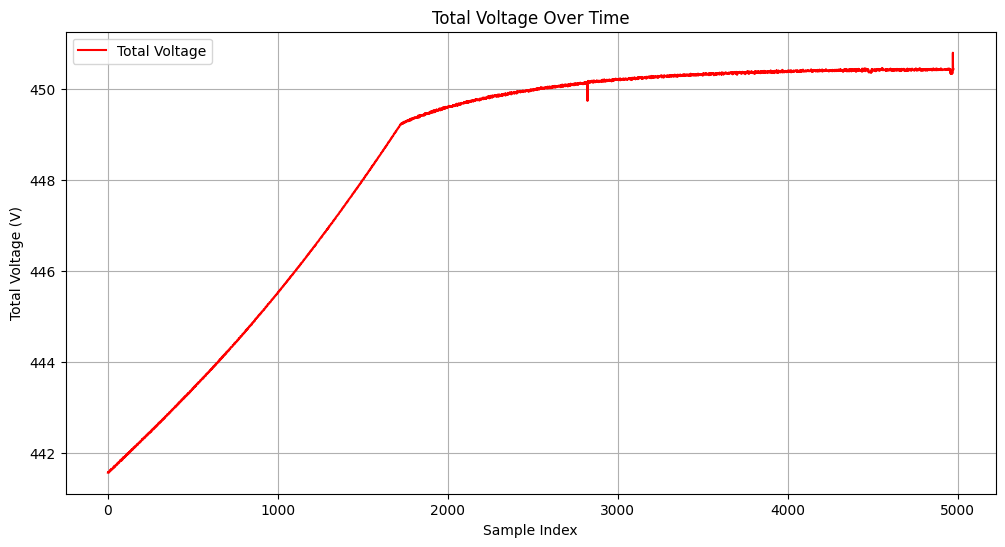

In [4]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(total_v, color='red', label='Total Voltage')
plt.title('Total Voltage Over Time')
plt.xlabel('Sample Index')
plt.ylabel('Total Voltage (V)')
plt.grid(True)
plt.legend()
plt.show()

In [5]:
# Design Butterworth lowpass filter
fs = 1000
cutoff_freq = 45  # Cutoff frequency
order = 1  # Filter order
b, a = signal.butter(order, cutoff_freq / (fs/2), btype='low', analog=False)

# Apply the filter
y = signal.lfilter(b, a, total_v)

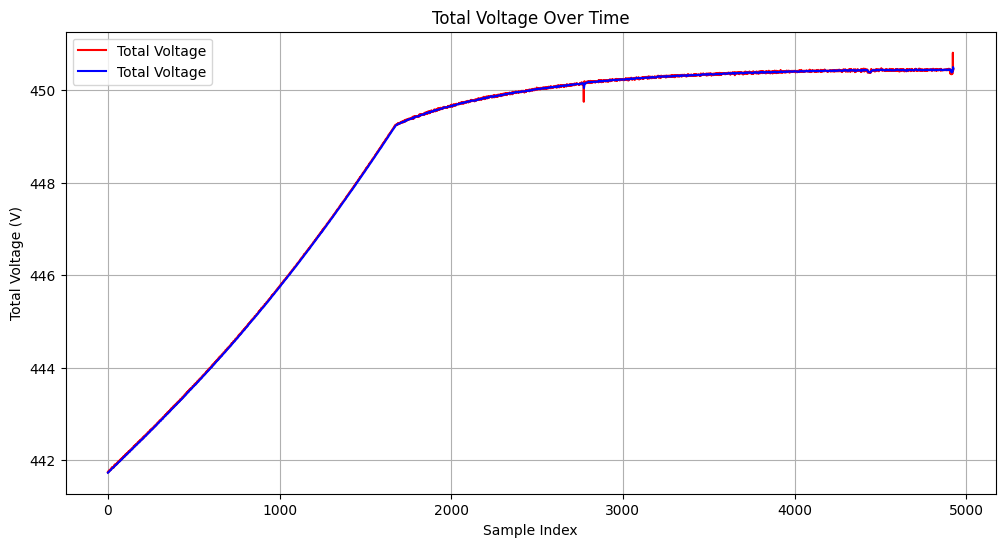

In [6]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(total_v[50:], color='red', label='Total Voltage')
plt.plot(y[50:], color='blue', label='Total Voltage')
plt.title('Total Voltage Over Time')
plt.xlabel('Sample Index')
plt.ylabel('Total Voltage (V)')
plt.grid(True)
plt.legend()
plt.show()